In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import minimize

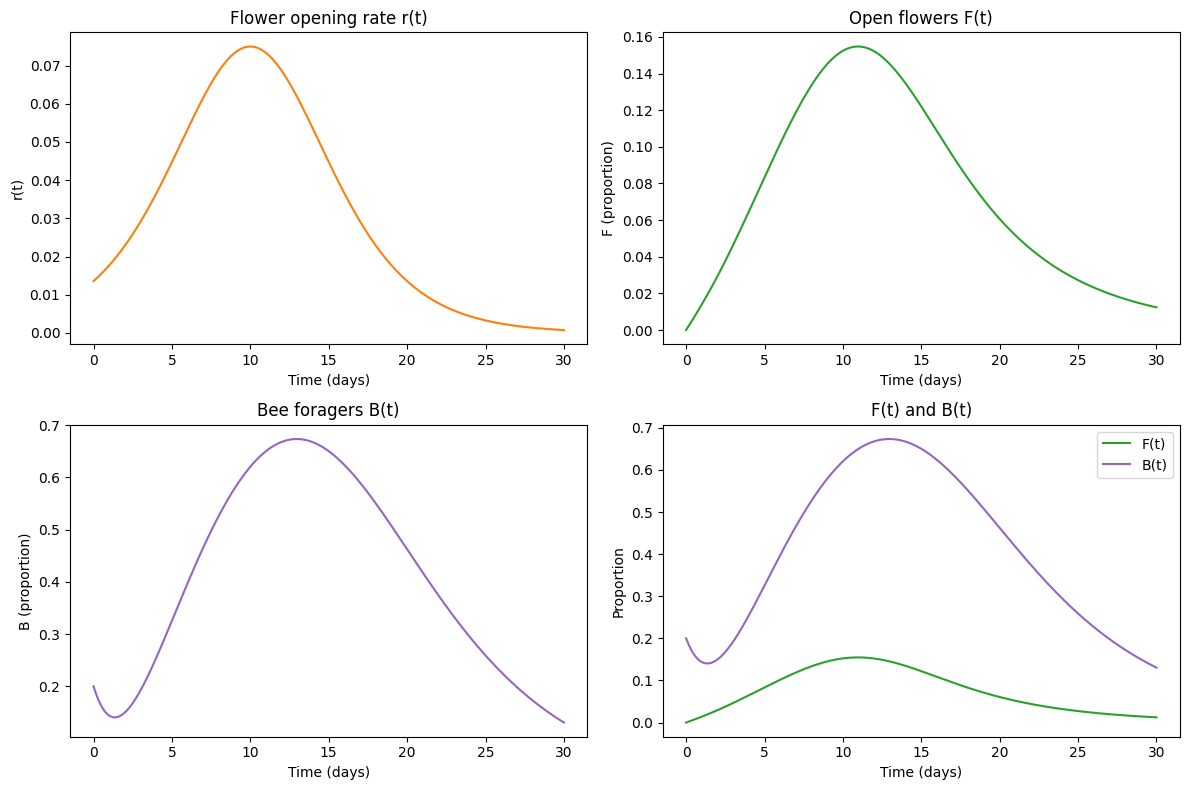

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ------------------------
# Parameters
# ------------------------

k = 0.3       # steepness of logistic (1/day)
t0 = 10.0     # center of bloom pulse (days)

mu_F = 0.15   # natural flower closing rate
sigma = 0.5   # pollination-driven flower "removal" rate

alpha = 0.8   # bee recruitment strength
h = 0.2       # half-saturation for F in bee recruitment
mu_B = 0.5    # bee loss rate

T_end = 30
t_eval = np.linspace(0, T_end, 400)

# ------------------------
# Opening rate r(t) as derivative of logistic
# ------------------------

def r_open(t, k=k, t0=t0):
    """
    Flower opening rate (proportion per day):
    r(t) = k e^{-k(t - t0)} / (1 + e^{-k(t - t0)})^2
    """
    z = np.exp(-k * (t - t0))
    return k * z / (1.0 + z)**2

# ------------------------
# ODE system with your new dF/dt and dB/dt
# ------------------------

def fb_system(t, y, k, t0, mu_F, sigma, alpha, h, mu_B):
    F, B = y

    # Flower opening rate
    r_t = r_open(t, k=k, t0=t0)

    # dF/dt = opening - natural closing - pollination-driven loss
    dFdt = r_t - mu_F * F - sigma * B * F

    # dB/dt = recruitment - loss
    if F > 0:
        dBdt = alpha * F / (F + h) - mu_B * B
    else:
        dBdt = -mu_B * B

    return [dFdt, dBdt]

# ------------------------
# Solve ODE
# ------------------------

F0 = 0.0   # no open flowers
B0 = 0.2   # some baseline bees
y0 = (F0, B0)

sol = solve_ivp(
    fb_system,
    (0, T_end),
    y0,
    t_eval=t_eval,
    args=(k, t0, mu_F, sigma, alpha, h, mu_B),
    rtol=1e-6,
    atol=1e-9,
)

t = sol.t
F = np.clip(sol.y[0], 0, 1)
B = np.clip(sol.y[1], 0, 1)

# ------------------------
# Plots
# ------------------------

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Opening pulse r(t)
ax[0, 0].plot(t, r_open(t), color='tab:orange')
ax[0, 0].set_title('Flower opening rate r(t)')
ax[0, 0].set_xlabel('Time (days)')
ax[0, 0].set_ylabel('r(t)')

# Open flowers F(t)
ax[0, 1].plot(t, F, color='tab:green')
ax[0, 1].set_title('Open flowers F(t)')
ax[0, 1].set_xlabel('Time (days)')
ax[0, 1].set_ylabel('F (proportion)')

# Bees B(t)
ax[1, 0].plot(t, B, color='tab:purple')
ax[1, 0].set_title('Bee foragers B(t)')
ax[1, 0].set_xlabel('Time (days)')
ax[1, 0].set_ylabel('B (proportion)')

# Combined F and B
ax[1, 1].plot(t, F, label='F(t)', color='tab:green')
ax[1, 1].plot(t, B, label='B(t)', color='tab:purple')
ax[1, 1].set_title('F(t) and B(t)')
ax[1, 1].set_xlabel('Time (days)')
ax[1, 1].set_ylabel('Proportion')
ax[1, 1].legend()

plt.tight_layout()
plt.show()

